In [ ]:
using LinearAlgebra
using BSplineKit
using PyCall
using DelimitedFiles
using Plots
using NonlinearEigenproblems
include("BaseFlow_cavity.jl")
include("Stability_Cavity.jl")

mode = 1:cavity; mode = 2:stationary; mode = 3:rotation;


Main.CRC_STA

In [10]:
Res = 1000
N_cheb = 129
mode = 1
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0.2
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

([-1.5645272952653226e-21; 0.0021084394200096964; … ; -0.0009584750804482187; -3.276454134516417e-19;;], [1.0; 0.99736909420173; … ; 0.0007876056035440407; -1.3959169145199874e-19;;], [-0.2; -0.2000099002686386; … ; -4.496103101683908e-6; 4.235164736271502e-21;;])

In [ ]:
R = 275
be = 0.16
OMEGA = 8.0
omega = -0.102
c = 0.01
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= CRC_STA.assemble_mat(cof,D,D2,be,omega,R)     
L0,L1,L2 = CRC_STA.boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3,maxit = 500 , tol=1e-14)
vel = CRC_STA.eig_full(eigvec,N_cheb,1)
@show eigval

In [ ]:
TITLE = "Flow Field Visualization"
VARIABLES = "X", "Y", "Z", "U" ,"V" 
ZONE T="Step_01", I=1, J=121, K=29, F=POINT

In [39]:
R = 420
be =  0.0
alpha = 0.29
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
# for alpha = 0.001 : 0.005 : 0.7
H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
C = eigen(H0,H1)
val = C.values
vec = C.vectors
map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.02, val)
val_filter0 = val[map_index0]
vec_filter0 = vec[:,map_index0]
indictor = sum(real(val_filter0))/length(val_filter0)
if alpha < 0.031
    addition = 0.004
else
    addition = 0.01
end
map_index = map(x-> (real(x)) > abs(indictor) + addition , val_filter0)
val_filter1 = val_filter0[map_index]
vec_filter1 = vec_filter0[:,map_index]
val_filter2 = val_filter1[findmax(imag.(val_filter1))[2]]
vec_filter2 = vec_filter1[:,findmax(imag.(val_filter1))[2]];
if 0.2 < alpha < 0.4
    # map_index1 = map(x-> abs(imag(x)) < (alpha * 100 ) * abs(imag(val_filter2)), val_filter1)
    idx = partialsortperm(real(val_filter1), 1:3, by = x -> abs(x - real(val_filter2)))
    val_filter = val_filter1[idx]
    vec_filter = vec_filter1[:,idx]
else
    val_filter = val_filter2
    vec_filter = vec_filter2
end
val_target = val_filter
vec_target = vec_filter
println("$(alpha)")
val_target

0.29


3-element Vector{ComplexF64}:
 0.03494121606424336 - 0.0005874202080015101im
 0.03273750337332862 - 0.0025074495934607824im
 0.02819788291959696 - 0.019052951821249296im

In [41]:
val = val_target[1] 
vec = vec_target[:,1]
dir = -1
writedlm("test.dat",[])
for be = 0.0 : dir * 0.005 : dir * 0.3 
    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
    val,vec = rayleigh_quotient_iteration(H0, H1, val+ 0.01im, vec)
    open("test.dat","a") do io
        writedlm(io,[R alpha be real(val) imag(val)])
    end
end

In [45]:
data = readdlm("test.dat")

61×5 Matrix{Float64}:
 420.0  0.29   0.0    0.0349412  -0.00058742
 420.0  0.29  -0.005  0.0371741  -0.000118647
 420.0  0.29  -0.01   0.0394226   0.000228418
 420.0  0.29  -0.015  0.0416791   0.000498083
 420.0  0.29  -0.02   0.0439462   0.000710588
 420.0  0.29  -0.025  0.0462275   0.000876819
 420.0  0.29  -0.03   0.0485262   0.00100344
 420.0  0.29  -0.035  0.0508454   0.00109501
 420.0  0.29  -0.04   0.0531879   0.00115494
 420.0  0.29  -0.045  0.0555562   0.0011861
   ⋮                             
 420.0  0.29  -0.26   0.177981   -0.00034665
 420.0  0.29  -0.265  0.181045   -0.000368391
 420.0  0.29  -0.27   0.184114   -0.000390252
 420.0  0.29  -0.275  0.187187   -0.000412218
 420.0  0.29  -0.28   0.190265   -0.000434274
 420.0  0.29  -0.285  0.193347   -0.000456408
 420.0  0.29  -0.29   0.196434   -0.000478612
 420.0  0.29  -0.295  0.199524   -0.000500877
 420.0  0.29  -0.3    0.202618   -0.000523196

In [46]:
data

61×5 Matrix{Float64}:
 420.0  0.29   0.0    0.0349412  -0.00058742
 420.0  0.29  -0.005  0.0371741  -0.000118647
 420.0  0.29  -0.01   0.0394226   0.000228418
 420.0  0.29  -0.015  0.0416791   0.000498083
 420.0  0.29  -0.02   0.0439462   0.000710588
 420.0  0.29  -0.025  0.0462275   0.000876819
 420.0  0.29  -0.03   0.0485262   0.00100344
 420.0  0.29  -0.035  0.0508454   0.00109501
 420.0  0.29  -0.04   0.0531879   0.00115494
 420.0  0.29  -0.045  0.0555562   0.0011861
   ⋮                             
 420.0  0.29  -0.26   0.177981   -0.00034665
 420.0  0.29  -0.265  0.181045   -0.000368391
 420.0  0.29  -0.27   0.184114   -0.000390252
 420.0  0.29  -0.275  0.187187   -0.000412218
 420.0  0.29  -0.28   0.190265   -0.000434274
 420.0  0.29  -0.285  0.193347   -0.000456408
 420.0  0.29  -0.29   0.196434   -0.000478612
 420.0  0.29  -0.295  0.199524   -0.000500877
 420.0  0.29  -0.3    0.202618   -0.000523196

In [50]:
data_1 = data[end:-1 : 1,:]
writedlm("test.dat",data_1)

In [92]:
val_filter2
# imag.(val_target[1])

0.0432178369575622 + 0.0006099219598703281im

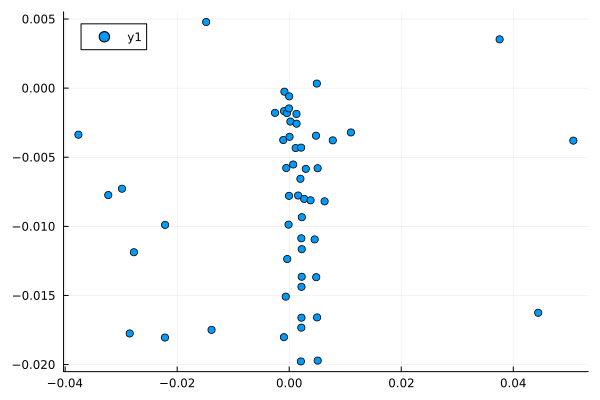

In [5]:
scatter(real(val_filter0),imag(val_filter0))

In [7]:
function rayleigh_quotient_iteration(A, B, sigma, q0=rand(ComplexF64, size(A, 1)))
    tol = 1e-8
    sigma_current = ComplexF64(sigma[1]) 
    q = q0 / norm(q0) # 必须使用欧几里得范数
    
    for i in 1:20
        sigma_old = sigma_current
        
        v = (A - sigma_current * B) \ (B * q)
        q = v / norm(v)
        
        num = dot(q, A * q)
        den = dot(q, B * q)
        sigma_current = num / den
        
        if abs(sigma_current - sigma_old) < tol
            return sigma_current, q
        end
    end
    @warn "RQI failed to converge"
    return sigma_current, q
end

rayleigh_quotient_iteration (generic function with 2 methods)